In [141]:
import os
import pickle
import numpy as np
import pandas as pd
import neurokit2 as nk
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.signal import butter, filtfilt, find_peaks

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier
from scipy.signal import resample

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import onnx
from onnx_tf.backend import prepare

from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    matthews_corrcoef, roc_auc_score
)

2026-02-05 17:36:44.320696: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-05 17:36:44.343818: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-05 17:36:45.172439: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-05 17:36:45.172635: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not 

ModuleNotFoundError: No module named 'tensorflow_addons'

In [135]:
DATA_PATH = "../data/WESAD"
FS = 700
WINDOW_SEC = 2
STEP_SEC = 2

SUBJECT_IDS = (
    [f"S{i}" for i in range(2, 12)] +
    [f"S{i}" for i in range(13, 18)]
)

def load_subject(path):
    with open(path, "rb") as f:
        return pickle.load(f, encoding="latin1")

def downsample_label(x, fs_high, fs_low):
    x = np.asarray(x)
    T = len(x) / fs_high
    n_out = int(round(T * fs_low))

    # time stamps for input samples
    t = np.arange(len(x)) / fs_high

    # bin edges for output samples (uniform in time)
    edges = np.linspace(0, T, n_out + 1)

    y = np.empty(n_out, dtype=float)
    for i in range(n_out):
        mask = (t >= edges[i]) & (t < edges[i+1])
        if mask.any():
            y[i] = np.bincount(x[mask], minlength=8).argmax()
        else:
            # rare edge case if rounding creates an empty bin
            y[i] = y[i-1] if i > 0 else x[0]
    return y

def upsample(low_signal, high_signal, fs_high, fs_low):
    upsample_factor = fs_high / fs_low

    # Compute target length
    target_len = len(high_signal)

    # Repeat each low-frequency sample
    indices = np.floor(np.arange(target_len) / upsample_factor).astype(int)
    indices = np.clip(indices, 0, len(low_signal) - 1)

    return low_signal[indices]




In [136]:

x = []
y = []

for sid in SUBJECT_IDS:
    print(sid)
    subject = load_subject(f"{DATA_PATH}/{sid}/{sid}.pkl")

    labels = np.array(subject['label'])
    #labels = downsample_label(labels, 700, FS)
    temp = np.array(subject['signal']['wrist']['TEMP'])
    temp = upsample(temp, labels, FS, 4)
    bvp = np.array(subject['signal']['wrist']['BVP'])
    bvp = upsample(bvp, labels, FS, 64)
    acc = np.array(subject['signal']['wrist']['ACC'])
    acc = upsample(acc, labels, FS, 32)
    

    WINDOW = FS * WINDOW_SEC
    STEP = FS * STEP_SEC

    for start in range(0, len(temp) - WINDOW, STEP):
        end = start + WINDOW
        temp_s = temp[start:end]
        bvp_s = bvp[start:end]
        acc_s = acc[start:end]

        label_s = (np.bincount(labels[start:end], minlength=8)[1:5].argmax() == 1).astype(int)

        x_s = np.concatenate([temp_s[:,0], bvp_s[:,0], acc_s[:,0], acc_s[:,1], acc_s[:,2]])
        x.append(x_s)
        y.append(label_s)


x = np.array(x)
y = np.array(y)
print(x.shape)
print(y.shape)

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2, stratify=y)
    

S2
S3
S4
S5
S6
S7
S8
S9
S10
S11
S13
S14
S15
S16
S17
(43423, 7000)
(43423,)


[0]	validation_0-logloss:0.57086	validation_0-error:0.11606
[1]	validation_0-logloss:0.56169	validation_0-error:0.11606
[2]	validation_0-logloss:0.55329	validation_0-error:0.11606
[3]	validation_0-logloss:0.54649	validation_0-error:0.13414
[4]	validation_0-logloss:0.54049	validation_0-error:0.19263
[5]	validation_0-logloss:0.53529	validation_0-error:0.20288
[6]	validation_0-logloss:0.53074	validation_0-error:0.21796
[7]	validation_0-logloss:0.52706	validation_0-error:0.22176
[8]	validation_0-logloss:0.52360	validation_0-error:0.23477
[9]	validation_0-logloss:0.52129	validation_0-error:0.23915
[10]	validation_0-logloss:0.51900	validation_0-error:0.24675
[11]	validation_0-logloss:0.51719	validation_0-error:0.24537
[12]	validation_0-logloss:0.51538	validation_0-error:0.24675
[13]	validation_0-logloss:0.51409	validation_0-error:0.25573
[14]	validation_0-logloss:0.51300	validation_0-error:0.25066
[15]	validation_0-logloss:0.51230	validation_0-error:0.25642
[16]	validation_0-logloss:0.51240	

<Axes: >

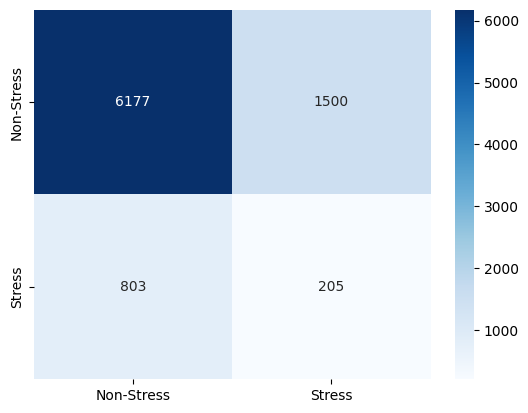

In [139]:
# ===================TEST XGB ======================================
xgb = XGBClassifier(
    n_estimators=30,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y == 0).sum() / (y == 1).sum(),
    tree_method = 'hist',
    eval_metric=["logloss", "error"])

xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
)

pred = xgb.predict(X_test)
cm = confusion_matrix(y_test, pred)
sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Non-Stress", "Stress"],
        yticklabels=["Non-Stress", "Stress"]
    )

Epoch [1/50] - Loss: 1.3880
Epoch [2/50] - Loss: 0.6614
Epoch [3/50] - Loss: 0.5529
Epoch [4/50] - Loss: 0.4651
Epoch [5/50] - Loss: 0.4313
Epoch [6/50] - Loss: 0.4212
Epoch [7/50] - Loss: 0.4066
Epoch [8/50] - Loss: 0.3980
Epoch [9/50] - Loss: 0.3687
Epoch [10/50] - Loss: 0.3478
Epoch [11/50] - Loss: 0.3397
Epoch [12/50] - Loss: 0.3338
Epoch [13/50] - Loss: 0.3209
Epoch [14/50] - Loss: 0.2944
Epoch [15/50] - Loss: 0.2987
Epoch [16/50] - Loss: 0.2818
Epoch [17/50] - Loss: 0.2704
Epoch [18/50] - Loss: 0.2657
Epoch [19/50] - Loss: 0.2603
Epoch [20/50] - Loss: 0.2446
Epoch [21/50] - Loss: 0.2359
Epoch [22/50] - Loss: 0.2414
Epoch [23/50] - Loss: 0.2298
Epoch [24/50] - Loss: 0.2171
Epoch [25/50] - Loss: 0.2204
Epoch [26/50] - Loss: 0.2090
Epoch [27/50] - Loss: 0.2113
Epoch [28/50] - Loss: 0.2084
Epoch [29/50] - Loss: 0.2034
Epoch [30/50] - Loss: 0.1862
Epoch [31/50] - Loss: 0.1812
Epoch [32/50] - Loss: 0.1884
Epoch [33/50] - Loss: 0.1906
Epoch [34/50] - Loss: 0.2195
Epoch [35/50] - Loss: 0

<Axes: >

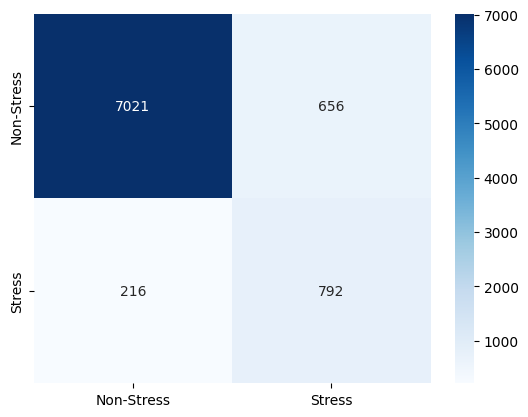

In [138]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(7000, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, 2)
        )

    def forward(self, x):
        return self.net(x)
    
device = "cuda:0"

model = MLP().to(torch.float64).to(device)
class_weight = torch.tensor([1.0,9.0]).to(torch.float64).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weight)
optimizer = optim.AdamW(model.parameters(), lr=1e-4)


dataset = TensorDataset(torch.tensor(x), torch.tensor(y))
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(
    dataset,
    [train_size, test_size]
)
dataloader_tr = DataLoader(train_dataset, batch_size=32, shuffle=True)
dataloader_te = DataLoader(test_dataset, batch_size=32, shuffle=True)

num_epochs = 50

for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0

    for batch_x, batch_y in dataloader_tr:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        # Forward pass
        logits = model(batch_x)
        loss = criterion(logits, batch_y)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader_tr)
    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {avg_loss:.4f}")

model.eval()
correct = 0
total = 0

y_test = []
pred = []

with torch.no_grad():
    for x, y in dataloader_te:
        x, y = x.to(device), y.to(device)

        logits = model(x)
        preds = logits.argmax(dim=1)

        y_test.extend(y.cpu())
        pred.extend(preds.cpu())

        correct += (preds == y).sum().item()
        total += y.size(0)

accuracy = correct / total
print(f"Test accuracy: {accuracy:.4f}")
print(y_test)
print(pred)
cm = confusion_matrix(y_test, pred)
sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Non-Stress", "Stress"],
        yticklabels=["Non-Stress", "Stress"]
    )

In [142]:
torch.onnx.export(
    model,
    torch.randn(1, 7000),
    "model.onnx", # Output file name
    input_names=["input"],
    output_names=["output"],
    opset_version=11, # Use a compatible opset version
)
print("✅ Model exported to model.onnx")



W0205 17:38:13.639000 110937 torch/onnx/_internal/exporter/_compat.py:114] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


ModuleNotFoundError: No module named 'onnxscript._framework_apis.torch_2_9'

In [99]:
print(np.bincount(y))
print(np.bincount(y_test))

[19203  2504]
[3841  501]
